# Warfarin PK/PD — Reproducing the Monolix Case Study with **nlmixr2**

This notebook reproduces, step by step, the MonolixSuite tutorial  
[*"Modeling the pharmacokinetics and pharmacodynamics of warfarin in healthy volunteers"*](https://monolixsuite.slp-software.com/tutorials/2024R1/modeling-the-pharmacokinetics-and-pharmacodynamics)  
using the **nlmixr2 / rxode2** ecosystem in R.

> ⚠️ This notebook requires an **R kernel (IRkernel)** in Jupyter.

## Learning objectives
- Build a population PK model incrementally (structure → residual error → covariates)
- Assess convergence robustness via multi-seed fitting
- Extend PK to PK/PD: compare *indirect response (turnover)* vs *effect compartment* models
- Simulate a virtual clinical trial and compute a clinical endpoint

## Outline
1. Data import & exploratory analysis (PK + PCA)
2. PK model development: 1-compartment → + lag time → (test 2-compartment) → model selection
3. Statistical model: residual error (combined1 vs combined2)
4. PK covariate: weight effect on V (power law)
5. PK diagnostics (GOF)
6. Convergence assessment (multiple seeds)
7. PK/PD development: *indirect response (turnover)* vs *effect compartment*
8. PK/PD diagnostics
9. Virtual clinical trial simulation + endpoint PCA(96h) < 35%
10. Replications with population parameter uncertainty

---

## 1 — Setup

In [20]:
# =============================================================================
# 0) Setup: packages and options
# =============================================================================
# Run install.packages() once if needed:
# install.packages(c("nlmixr2", "rxode2", "nlmixr2data",
#                    "dplyr", "tidyr", "purrr", "ggplot2", "readr",
#                    "stringr", "broom", "MASS"))

library(nlmixr2)
library(rxode2)
library(dplyr)
library(tidyr)
library(purrr)
library(ggplot2)
library(stringr)

set.seed(42)
rxSetSeed(42)

options(width = 120)
theme_set(theme_bw())

## 2 — Data Import & Formatting

We use the warfarin dataset embedded in `nlmixr2data` (identical to the Monolix tutorial dataset).

The dataset contains:
- **PK observations**: plasma warfarin concentration (`dvid == "cp"`)
- **PD observations**: prothrombin complex activity (`dvid == "pca"`)
- **Covariates**: body weight (`wt`), age, sex

In [21]:
# =============================================================================
# 1) Data: import + formatting
# =============================================================================
read_warfarin <- function() {
  if (requireNamespace("nlmixr2data", quietly = TRUE)) {
    return(nlmixr2data::warfarin)
  }
  # Fallback: download from Monolix website
  url <- "https://monolixsuite.slp-software.com/__attachments/49840458/warfarin_data.txt"
  tmp <- tempfile(fileext = ".txt")
  download.file(url, tmp, quiet = TRUE)
  read.table(tmp, header = TRUE, stringsAsFactors = FALSE)
}

dat_raw <- read_warfarin()

dat <- dat_raw %>%
  rename_with(tolower) %>%
  mutate(
    id   = as.integer(id),
    time = as.numeric(time),
    amt  = as.numeric(amt),
    dv   = as.numeric(dv),
    wt   = as.numeric(wt),
    age  = as.numeric(age)
  )

# Handle "." placeholders from Monolix-style flat files
if (is.character(dat$dv))  dat$dv  <- as.numeric(ifelse(dat$dv  == ".", NA,  dat$dv))
if (is.character(dat$amt)) dat$amt <- as.numeric(ifelse(dat$amt == ".", 0,   dat$amt))

# Add evid if missing: 1 = dosing record, 0 = observation
if (!"evid" %in% names(dat)) {
  dat <- dat %>% mutate(evid = ifelse(!is.na(amt) & amt > 0, 1L, 0L))
}

# Standardise dvid factor (Monolix: 1=PK, 2=PD)
if ("dvid" %in% names(dat)) {
  if (is.numeric(dat$dvid) || is.integer(dat$dvid)) {
    dat <- dat %>% mutate(dvid = factor(dvid, levels = c(1, 2), labels = c("cp", "pca")))
  } else {
    dat <- dat %>% mutate(dvid = as.factor(dvid))
  }
} else {
  stop("Column 'dvid' is required (cp vs pca).")
}

# Standardise sex factor (0 = female, 1 = male)
if ("sex" %in% names(dat)) {
  if (is.numeric(dat$sex) || is.integer(dat$sex)) {
    dat <- dat %>% mutate(sex = factor(sex, levels = c(0, 1), labels = c("female", "male")))
  } else {
    dat <- dat %>% mutate(sex = as.factor(dat$sex))
  }
}

# Propagate covariates to observation rows (fill forward/backward within subject)
dat <- dat %>%
  group_by(id) %>%
  fill(wt, age, .direction = "downup") %>%
  ungroup()

glimpse(dat)
cat("\nDVID breakdown:\n"); print(table(dat$dvid, useNA = "ifany"))

Rows: 515
Columns: 9
$ id   <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, …
$ time <dbl> 0.0, 0.5, 1.0, 2.0, 3.0, 6.0, 9.0, 12.0, 24.0, 24.0, 36.0, 36.0, 48.0, 48.0, 72.0, 72.0, 96.0, 120.0, 144…
$ amt  <dbl> 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10…
$ dv   <dbl> 0.0, 0.0, 1.9, 3.3, 6.6, 9.1, 10.8, 8.6, 5.6, 44.0, 4.0, 27.0, 2.7, 28.0, 0.8, 31.0, 60.0, 65.0, 71.0, 0.…
$ dvid <fct> cp, cp, cp, cp, cp, cp, cp, cp, cp, pca, cp, pca, cp, pca, cp, pca, pca, pca, pca, cp, pca, cp, pca, cp, …
$ evid <int> 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, …
$ wt   <dbl> 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.…
$ age  <dbl> 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 5…
$ sex  <fct> male, 

## 3 — Exploratory Data Analysis

We visualise:
- Warfarin plasma concentration profiles (PK)
- Prothrombin complex activity profiles (PD)
- PCA vs concentration hysteresis (evidence of a time delay between drug levels and effect)

> **Hysteresis** in the PCA vs Cp loop is the key observation motivating the PK/PD models below:
> the effect lags behind the concentration, suggesting either an effect-site delay or an indirect mechanism.

Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."


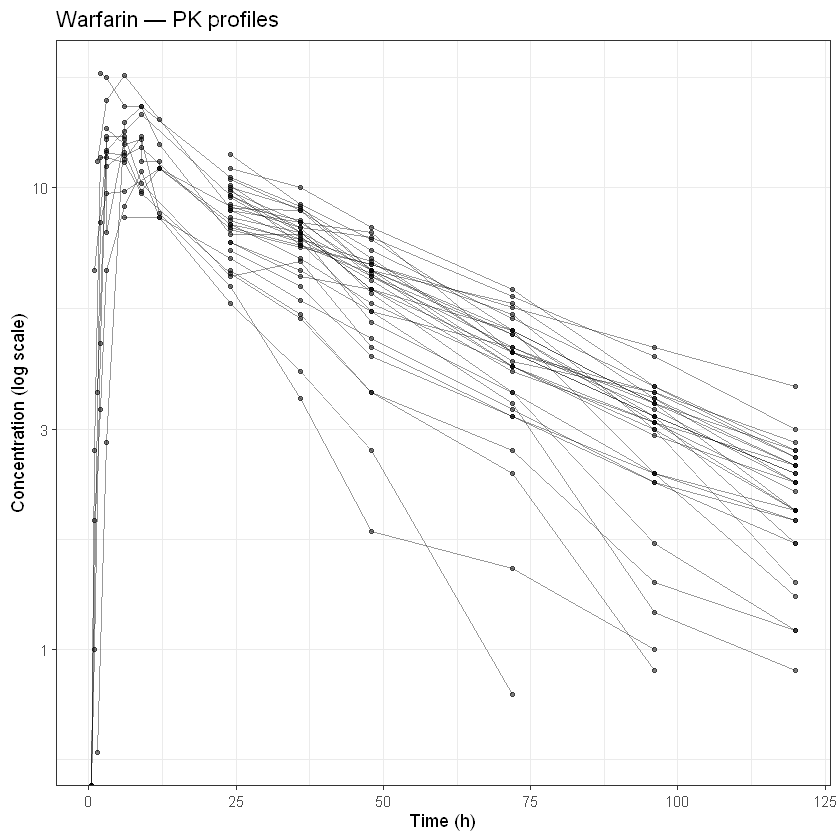

Warning message:
"Removed 47 rows containing missing values or values outside the scale range (`geom_path()`)."
Warning message:
"Removed 47 rows containing missing values or values outside the scale range (`geom_point()`)."


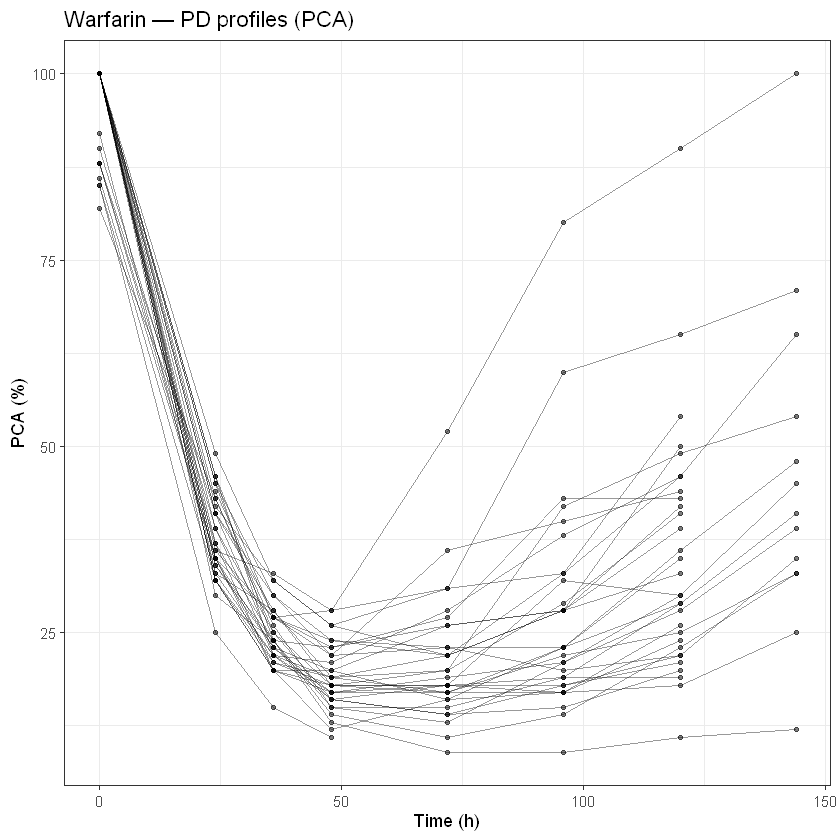

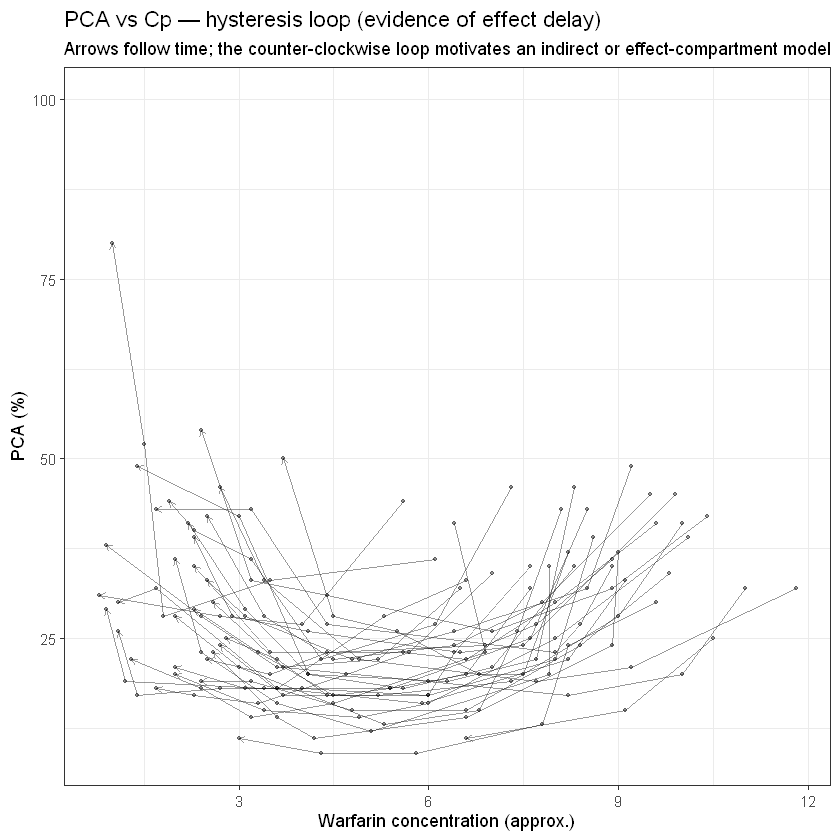

In [22]:
# =============================================================================
# 2) Exploratory plots
# =============================================================================
dat_pk <- dat %>% filter(dvid == "cp"  | evid == 1)
dat_pd <- dat %>% filter(dvid == "pca" | evid == 1)

# PK profiles (log scale)
p_pk <- ggplot(dat_pk %>% filter(evid == 0), aes(x = time, y = dv, group = id)) +
  geom_line(alpha = 0.4) +
  geom_point(alpha = 0.5, size = 1) +
  scale_y_log10() +
  labs(title = "Warfarin — PK profiles", x = "Time (h)", y = "Concentration (log scale)")

# PD profiles
p_pd <- ggplot(dat_pd %>% filter(evid == 0), aes(x = time, y = dv, group = id)) +
  geom_line(alpha = 0.4) +
  geom_point(alpha = 0.5, size = 1) +
  labs(title = "Warfarin — PD profiles (PCA)", x = "Time (h)", y = "PCA (%)")

print(p_pk)
print(p_pd)

# ── PCA vs Cp (hysteresis plot) ─────────────────────────────────────────────
# Interpolate Cp at PD observation times per subject
cp_interp <- dat_pk %>%
  filter(evid == 0) %>%
  select(id, time, cp = dv) %>%
  group_by(id) %>%
  arrange(time) %>%
  tidyr::complete(time = seq(min(time), max(time), by = 1)) %>%
  tidyr::fill(cp, .direction = "downup") %>%
  ungroup()

pca_pts <- dat_pd %>%
  filter(evid == 0) %>%
  select(id, time, pca = dv)

effconc <- pca_pts %>% left_join(cp_interp, by = c("id", "time"))

p_ec <- ggplot(effconc, aes(x = cp, y = pca, group = id)) +
  geom_path(alpha = 0.4, arrow = arrow(length = unit(0.15, "cm"))) +
  geom_point(alpha = 0.4, size = 0.8) +
  labs(
    title = "PCA vs Cp — hysteresis loop (evidence of effect delay)",
    subtitle = "Arrows follow time; the counter-clockwise loop motivates an indirect or effect-compartment model",
    x = "Warfarin concentration (approx.)", y = "PCA (%)"
  )
print(p_ec)

## 4 — Helper Functions

We define two helpers used throughout the notebook:
- `safe_nlmixr()`: wraps `nlmixr()` with error catching so a failed fit does not abort the notebook
- `metrics()`: extracts AIC, BIC, log-likelihood from a fit object

In [23]:
# =============================================================================
# Helper utilities
# =============================================================================

#' Safe nlmixr wrapper — returns NULL instead of throwing on error
safe_nlmixr <- function(model, data, est = "saem", seed = 1,
                        control = saemControl(print = 50),
                        table   = tableControl(cwres = TRUE, npde = TRUE)) {
  set.seed(seed)
  rxSetSeed(seed)
  tryCatch(
    nlmixr(model, data, est = est, control = control, table = table),
    error = function(e) {
      message("\u26a0\ufe0f  Fit failed: ", conditionMessage(e))
      NULL
    }
  )
}

#' Extract AIC / BIC / logLik from a fit (or return NA if fit is NULL)
metrics <- function(fit, name) {
  if (is.null(fit))
    return(tibble(model = name, AIC = NA_real_, BIC = NA_real_, logLik = NA_real_))
  tibble(
    model  = name,
    AIC    = AIC(fit),
    BIC    = BIC(fit),
    logLik = as.numeric(logLik(fit))
  )
}

## 5 — PK Model Development

### Strategy (mirrors the Monolix tutorial)
We compare three increasingly complex structural models:

| Model | Description |
|-------|-------------|
| r01 | 1-compartment, first-order oral absorption, no lag |
| r02 | 1-compartment + absorption lag time (*Tlag*) |
| r03 | 2-compartment + lag time (optional, often over-parameterised) |

**Parameterisation**: all fixed effects are log-transformed (`tka = log(Ka)`, etc.) to enforce positivity.  
**Random effects**: one ETA per parameter, log-normal IIV.  
**Residual error**: `combined1` as starting point (mixture on the SD scale).

In [ ]:
# =============================================================================
# 3.1  PK — 1-compartment, no lag (starting model)
# =============================================================================
pk_1cmt_c1 <- function() {
  ini({
    tka <- log(1.0)
    tcl <- log(0.1)
    tv  <- log(10)

    eta.ka ~ 0.3
    eta.cl ~ 0.1
    eta.v  ~ 0.1

    add.sd  <- 0.1
    prop.sd <- 0.1
  })
  model({
    ka <- exp(tka + eta.ka)
    cl <- exp(tcl + eta.cl)
    v  <- exp(tv  + eta.v)

    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr

    cp = centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined1() 
  })
}

fit_pk_r01 <- safe_nlmixr(pk_1cmt_c1, dat_pk, seed = 101)

# =============================================================================
# 3.2  PK — 1-compartment + Tlag
# =============================================================================
# Adding an absorption lag time accounts for the delay before drug enters
# the systemic circulation (e.g., gastric emptying, dissolution).
pk_1cmt_tlag_c1 <- function() {
  ini({
    ttlag <- log(0.5)
    tka   <- log(1.0)
    tcl   <- log(0.1)
    tv    <- log(10)

    eta.tlag ~ 0.1
    eta.ka   ~ 0.3
    eta.cl   ~ 0.1
    eta.v    ~ 0.1

    add.sd  <- 0.1
    prop.sd <- 0.1
  })
  model({
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv    + eta.v)

    alag(depot) = tlag

    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr

    cp = centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined1() 
  })
}
fit_pk_r02 <- safe_nlmixr(pk_1cmt_tlag_c1, dat_pk, seed = 102)

# =============================================================================
# 3.3  PK — 2-compartment + Tlag  (optional; may be over-parameterised)
# =============================================================================
pk_2cmt_tlag_c1 <- function() {
  ini({
    ttlag <- log(0.5)
    tka   <- log(1.0)
    tcl   <- log(0.1)
    tv    <- log(10)
    tq    <- log(5.0)
    tvp   <- log(20)

    eta.tlag ~ 0.1
    eta.ka   ~ 0.3
    eta.cl   ~ 0.1
    eta.v    ~ 0.1
    
    add.sd  <- 0.1
    prop.sd <- 0.1
  })
  model({
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv    + eta.v)
    q    <- exp(tq)
    vp   <- exp(tvp)

    alag(depot) = tlag

    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr - (q / v) * centr + (q / vp) * peri
    d/dt(peri)  =  (q / v) * centr - (q / vp) * peri

    cp = centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined1() | cp
  })
}

fit_pk_r03 <- safe_nlmixr(pk_2cmt_tlag_c1, dat_pk, seed = 103)

# ── Model comparison ─────────────────────────────────────────────────────────
bind_rows(
  metrics(fit_pk_r01, "r01: 1-cmt, no lag"),
  metrics(fit_pk_r02, "r02: 1-cmt + Tlag"),
  metrics(fit_pk_r03, "r03: 2-cmt + Tlag")
) %>% arrange(BIC)

 

 

 

 

ℹ parameter labels from comments are typically ignored in non-interactive mode

ℹ Need to run with the source intact to parse comments

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

using C compiler: 'gcc.exe (GCC) 13.3.0'


ℹ calculate uninformed etas

ℹ done

params:	tka	tcl	tv	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

→ Calculating residuals/tables

→ l

model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
r02: 1-cmt + Tlag,781.8434,817.0979,-380.9217
r03: 2-cmt + Tlag,817.0512,859.3567,-396.5256
"r01: 1-cmt, no lag",899.6142,927.8178,-441.8071


## 6 — Residual Error Model: combined1 vs combined2

Monolix uses **combined2** (variance-scale mixture) as the default:
$$\sigma^2_{tot} = \sigma^2_{add} + \sigma^2_{prop} \cdot f^2$$

In nlmixr2/rxode2:
- `combined1()` — mixture on the **SD** scale: $\sigma_{tot} = \sigma_{add} + \sigma_{prop}\cdot f$
- `combined2()` — mixture on the **variance** scale (Monolix default)

We refit the best structural model (1-cmt + Tlag) with `combined2` and compare.

In [25]:
# =============================================================================
# 4) Residual error: combined1 vs combined2
# =============================================================================

# Build the combined2 variant by piping model() onto the existing UI
base_ui <- if (!is.null(fit_pk_r02) && !is.null(fit_pk_r02$finalUi)) {
  fit_pk_r02$finalUi
} else {
  pk_1cmt_tlag_c1
}

pk_tlag_c2_ui <- base_ui %>%
  model({ cp ~ add(add.sd) + prop(prop.sd) + combined2() })

fit_pk_r02_c2 <- safe_nlmixr(pk_tlag_c2_ui, dat_pk, seed = 104)

bind_rows(
  metrics(fit_pk_r02,    "r02: 1-cmt + Tlag, combined1"),
  metrics(fit_pk_r02_c2, "r02b: 1-cmt + Tlag, combined2")
) %>% arrange(BIC)

# Retain the better model
fit_pk_struct_final <- if (!is.null(fit_pk_r02_c2)) fit_pk_r02_c2 else fit_pk_r02

→ significant model change detected

→ removed from model: '$control'

 

 

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	ttlag	tka	tcl	tv	V(eta.tlag)	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

→ Calculating residuals/tables

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of full model...

✔ done


model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
"r02b: 1-cmt + Tlag, combined2",760.3437,795.5982,-370.1718
"r02: 1-cmt + Tlag, combined1",781.8434,817.0979,-380.9217


## 7 — Covariate: Weight Effect on V (Power Law)

The Monolix tutorial identifies **body weight on V** as the most significant covariate:
$$V_i = V_{pop} \cdot \left(\frac{wt_i}{wt_{ref}}\right)^{\beta_{wt,V}} \cdot e^{\eta_{V,i}}$$

- $\beta_{wt,V}$ is estimated (allometric value close to 1 for volume).
- $wt_{ref}$ is fixed to the median weight of the population (prevents identifiability issues).

In [26]:
# =============================================================================
# 5) Covariate: weight on V
# =============================================================================

stopifnot("wt" %in% names(dat_pk))

# Reference weight: median across subjects
wt_ref_num <- dat_pk %>%
  distinct(id, wt) %>%
  summarise(med_wt = median(wt, na.rm = TRUE)) %>%
  pull(med_wt) %>%
  as.numeric()

cat("Reference weight (median):", wt_ref_num, "kg\n")

base_ui <- if (!is.null(fit_pk_struct_final) && !is.null(fit_pk_struct_final$finalUi)) {
  fit_pk_struct_final$finalUi
} else {
  pk_tlag_c2_ui
}

pk_cov_ui <- base_ui %>%
  model({
    ka  <- exp(tka + eta.ka)
    cl  <- exp(tcl + eta.cl)
    # Power-law weight effect: V scales with (wt/wt_ref)^beta
    v   <- exp(tv + b_wt_v * log(wt / wt_ref) + eta.v)
    cp  <- centr / v
    cp  ~ add(add.sd) + prop(prop.sd) + combined2()
  }) %>%
  ini({
    b_wt_v <- 1.0              # allometric exponent (start at 1)
    wt_ref  = fixed(wt_ref_num)  # fix reference weight
  })

fit_pk_cov <- safe_nlmixr(pk_cov_ui, dat_pk, seed = 105)

bind_rows(
  metrics(fit_pk_struct_final, "PK without covariate"),
  metrics(fit_pk_cov,          "PK + weight on V")
) %>% arrange(BIC)

fit_pk_final <- if (!is.null(fit_pk_cov)) fit_pk_cov else fit_pk_struct_final

Reference weight (median): 71.65 kg


ℹ add covariate `b_wt_v`

ℹ add covariate `wt`

ℹ add covariate `wt_ref`

→ significant model change detected

→ removed from model: '$control'

ℹ promote `b_wt_v` to population parameter with initial estimate 1

ℹ change initial estimate of `b_wt_v` to `1`

ℹ promote `wt_ref` to population parameter with initial estimate 71.65

ℹ fix `wt_ref` to `71.65`

ℹ change initial estimate of `wt_ref` to `71.65`

 

 

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	ttlag	tka	tcl	tv	b_wt_v	V(eta.tlag)	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly mo

model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
PK + weight on V,745.0237,783.8036,-361.5118
PK without covariate,760.3437,795.5982,-370.1718


## 8 — PK Diagnostics (GOF)

Standard goodness-of-fit plots:
1. **Observations vs PRED** (population predictions)  
2. **Observations vs IPRED** (individual predictions)  
3. **CWRES vs time** (conditional weighted residuals)

Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."


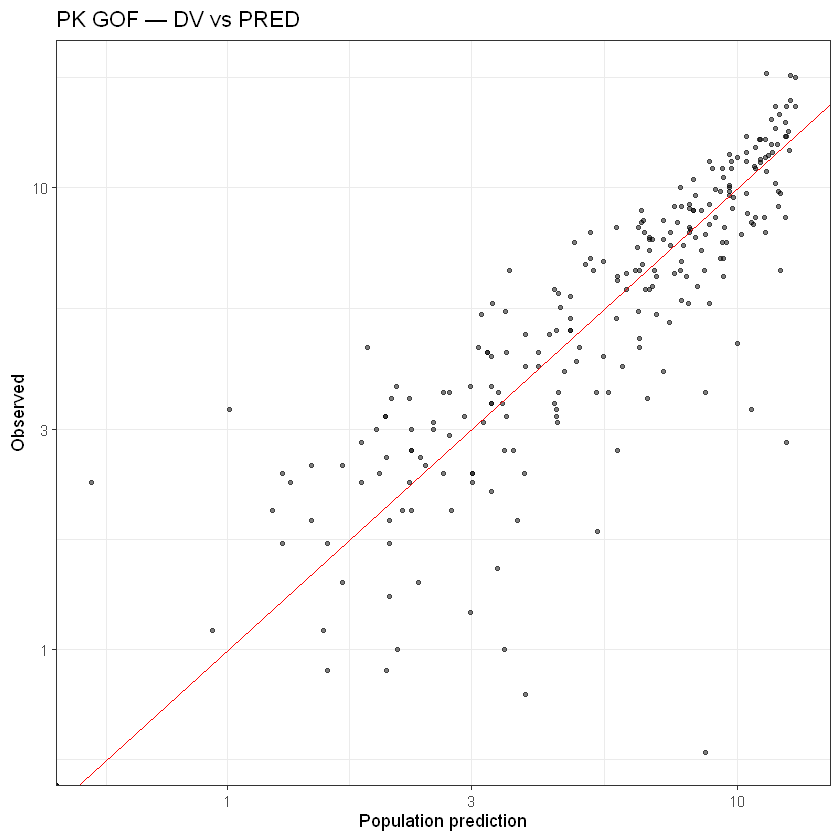

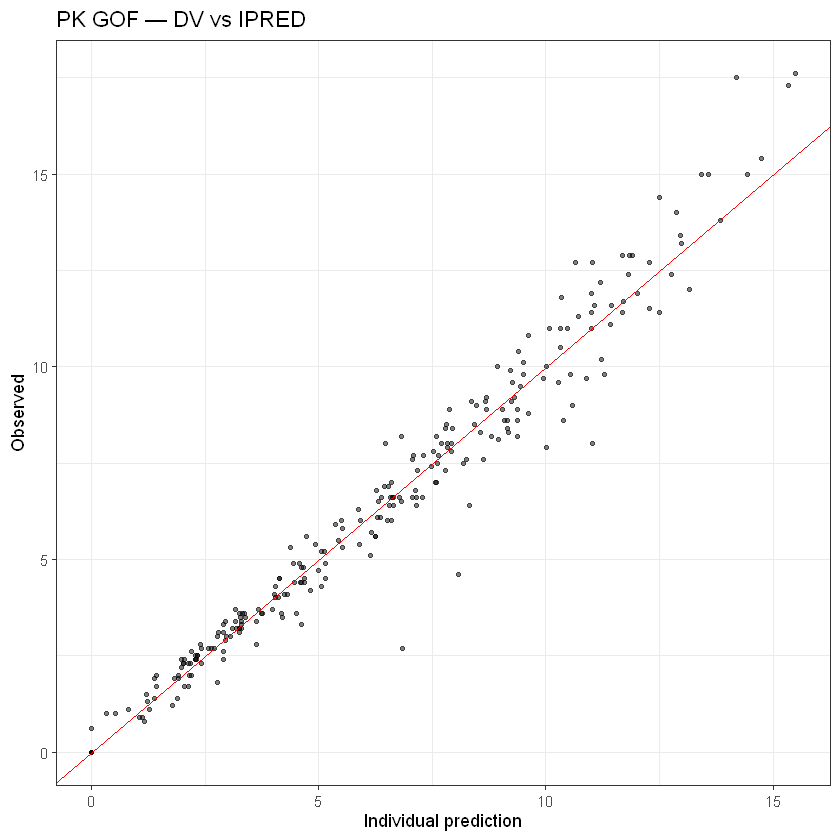

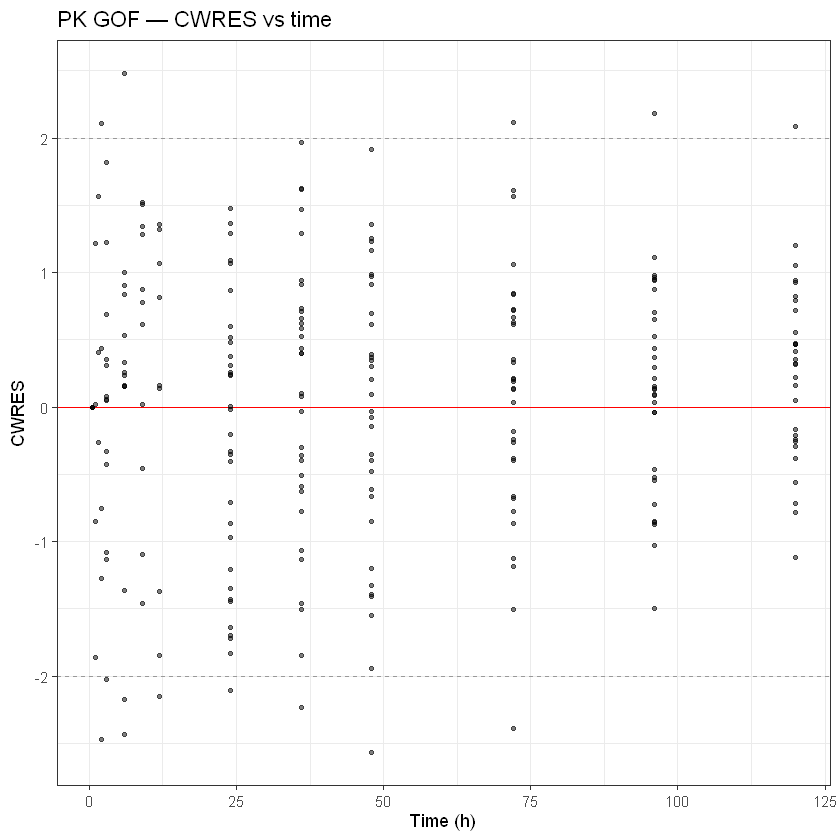

In [27]:
# =============================================================================
# 6) GOF diagnostics
# =============================================================================

if (!is.null(fit_pk_final)) {
  ap_df <- as.data.frame(fit_pk_final)

  if (all(c("DV", "PRED") %in% names(ap_df))) {
    print(
      ggplot(ap_df %>% filter(!is.na(DV)), aes(x = PRED, y = DV)) +
        geom_point(alpha = 0.5, size = 1) +
        geom_abline(slope = 1, intercept = 0, colour = "red") +
        scale_y_log10() + scale_x_log10() +
        labs(title = "PK GOF — DV vs PRED", x = "Population prediction", y = "Observed")
    )
  }

  if (all(c("DV", "IPRED") %in% names(ap_df))) {
    print(
      ggplot(ap_df %>% filter(!is.na(DV)), aes(x = IPRED, y = DV)) +
        geom_point(alpha = 0.5, size = 1) +
        geom_abline(slope = 1, intercept = 0, colour = "red") +
        labs(title = "PK GOF — DV vs IPRED", x = "Individual prediction", y = "Observed")
    )
  }

  if (all(c("TIME", "CWRES") %in% names(ap_df))) {
    print(
      ggplot(ap_df %>% filter(!is.na(CWRES)), aes(x = TIME, y = CWRES)) +
        geom_hline(yintercept = 0, colour = "red") +
        geom_hline(yintercept = c(-2, 2), linetype = "dashed", colour = "grey60") +
        geom_point(alpha = 0.5, size = 1) +
        labs(title = "PK GOF — CWRES vs time", x = "Time (h)", y = "CWRES")
    )
  }
}

## 9 — Convergence Assessment (Multiple Seeds)

We refit the final PK model with 5 different random seeds and compare the estimated parameters.  
**Stable estimates across seeds = good convergence**, regardless of starting point.

In [28]:
# =============================================================================
# 7) Convergence robustness: multiple seeds
# =============================================================================

if (!is.null(fit_pk_final)) {
  seeds <- c(11, 22, 33, 44, 55)

  ui_pk <- if (!is.null(fit_pk_final$finalUi)) fit_pk_final$finalUi else fit_pk_final$ui
  fits <- purrr::map(seeds, ~ safe_nlmixr(ui_pk, dat_pk, seed = .x))
  names(fits) <- paste0("seed_", seeds)

  fits_ok <- purrr::keep(fits, ~ !is.null(.x))

  coef_tbl <- purrr::imap_dfr(fits_ok, function(f, nm) {
    # Extraction robuste des thetas (effets fixes)
    theta <- tryCatch(nlmixr2::fixef(f), error = function(e) NULL)

    # Fallback si jamais fixef échoue (rare)
    if (is.null(theta)) {
      theta <- tryCatch({
        th <- f$theta
        if (is.null(th)) NULL else th
      }, error = function(e) NULL)
    }

    if (is.null(theta)) return(NULL)

    tibble::enframe(theta, name = "parameter", value = "estimate") %>%
      dplyr::mutate(seed = nm, .before = 1)
  })

  # ---- Table robustesse (résumé par paramètre) ----
  robust_tbl <- coef_tbl %>%
    dplyr::group_by(parameter) %>%
    dplyr::summarise(
      n_seeds = dplyr::n(),
      mean    = mean(estimate, na.rm = TRUE),
      sd      = sd(estimate, na.rm = TRUE),
      cv_pct  = 100 * sd / abs(mean),
      min     = min(estimate, na.rm = TRUE),
      max     = max(estimate, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    dplyr::arrange(dplyr::desc(cv_pct))

  print(robust_tbl, n = 200)

  # Optionnel : tableau wide
  coef_tbl %>%
    tidyr::pivot_wider(names_from = seed, values_from = estimate) %>%
    print(n = 200)
}

 

 

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	ttlag	tka	tcl	tv	b_wt_v	V(eta.tlag)	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

→ Calculating residuals/tables

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of full model...

✔ done

→ calculate jacobian

→ calculate sensitivities

→ calculate ∂(

# A tibble: 8 × 7
  parameter n_seeds   mean    sd cv_pct    min    max
  <chr>       <int>  <dbl> <dbl>  <dbl>  <dbl>  <dbl>
1 add.sd          5  0.379     0      0  0.379  0.379
2 b_wt_v          5  0.763     0      0  0.763  0.763
3 prop.sd         5  0.104     0      0  0.104  0.104
4 tcl             5 -2.02      0      0 -2.02  -2.02 
5 tka             5  0.353     0      0  0.353  0.353
6 ttlag           5 -0.251     0      0 -0.251 -0.251
7 tv              5  2.09      0      0  2.09   2.09 
8 wt_ref          5 71.6       0      0 71.6   71.6  
# A tibble: 8 × 6
  parameter seed_11 seed_22 seed_33 seed_44 seed_55
  <chr>       <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
1 ttlag      -0.251  -0.251  -0.251  -0.251  -0.251
2 tka         0.353   0.353   0.353   0.353   0.353
3 tcl        -2.02   -2.02   -2.02   -2.02   -2.02 
4 tv          2.09    2.09    2.09    2.09    2.09 
5 add.sd      0.379   0.379   0.379   0.379   0.379
6 prop.sd     0.104   0.104   0.104   0.104   0.104
7 b_wt_v

In [29]:
# Display PK estimates on the natural (untransformed) scale
coef_wide <- coef_tbl %>%
  dplyr::filter(parameter != "wt_ref") %>%
  tidyr::pivot_wider(names_from = seed, values_from = estimate)

print(coef_wide, n = 200, width = Inf)

# écart max entre seeds par paramètre
delta_tbl <- coef_tbl %>%
  dplyr::filter(parameter != "wt_ref") %>%
  dplyr::group_by(parameter) %>%
  dplyr::summarise(
    min = min(estimate),
    max = max(estimate),
    delta = max - min,
    .groups = "drop"
  )

print(delta_tbl, n = 200)

# A tibble: 7 × 6
  parameter seed_11 seed_22 seed_33 seed_44 seed_55
  <chr>       <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
1 ttlag      -0.251  -0.251  -0.251  -0.251  -0.251
2 tka         0.353   0.353   0.353   0.353   0.353
3 tcl        -2.02   -2.02   -2.02   -2.02   -2.02 
4 tv          2.09    2.09    2.09    2.09    2.09 
5 add.sd      0.379   0.379   0.379   0.379   0.379
6 prop.sd     0.104   0.104   0.104   0.104   0.104
7 b_wt_v      0.763   0.763   0.763   0.763   0.763
# A tibble: 7 × 4
  parameter    min    max delta
  <chr>      <dbl>  <dbl> <dbl>
1 add.sd     0.379  0.379     0
2 b_wt_v     0.763  0.763     0
3 prop.sd    0.104  0.104     0
4 tcl       -2.02  -2.02      0
5 tka        0.353  0.353     0
6 ttlag     -0.251 -0.251     0
7 tv         2.09   2.09      0


In [30]:
# Display PK estimates on the natural (untransformed) scale
if (exists("coef_tbl") && nrow(coef_tbl) > 0) {
  theta_hat <- coef_tbl %>%
    filter(seed == "seed_11") %>%
    select(parameter, estimate) %>%
    tibble::deframe()

  tibble::tibble(
    Tlag      = exp(theta_hat["ttlag"]),
    Ka        = exp(theta_hat["tka"]),
    CL        = exp(theta_hat["tcl"]),
    V_ref     = exp(theta_hat["tv"]),
    beta_wt_V = theta_hat["b_wt_v"],
    add_sd    = theta_hat["add.sd"],
    prop_sd   = theta_hat["prop.sd"]
  ) %>% print(width = Inf)
}

# A tibble: 1 × 7
   Tlag    Ka    CL V_ref beta_wt_V add_sd prop_sd
  <dbl> <dbl> <dbl> <dbl>     <dbl>  <dbl>   <dbl>
1 0.778  1.42 0.133  8.12     0.763  0.379   0.104


## 10 — PK/PD Development

### Background

In the Monolix tutorial, PCA (prothrombin complex activity) is modelled as a **pharmacodynamic response** to warfarin.  
Warfarin inhibits vitamin K epoxide reductase (VKOR), which is required for clotting factor synthesis.  
Because clotting factors have a finite half-life (~24 h), there is a **biological delay** between drug exposure and observed anticoagulant effect.

Two mechanistic model families are compared:

| Model | Mechanism | ODE |
|-------|-----------|-----|
| **Indirect response (turnover)** | Warfarin inhibits *production* of clotting factors | $\frac{d(\text{response})}{dt} = k_{in}(1-I) - k_{out}\cdot\text{response}$ |
| **Effect compartment** | Hysteresis due to slow distribution to the effect site | $\frac{d(c_e)}{dt} = k_{e0}(c_p - c_e)$ |

In both models, the inhibition function is a sigmoidal Hill equation:
$$I = \frac{I_{max}\cdot c^\gamma}{IC_{50}^\gamma + c^\gamma}$$

### PK parameter strategy
PK parameters estimated in Section 5 are **fixed** in the PK/PD models.  
This is the Monolix workflow: sequential modelling (first PK, then PD).

```

In [31]:
# =============================================================================
# 8) PK/PD: extract fixed PK parameters from the final PK fit
# =============================================================================

if (is.null(fit_pk_final)) stop("Final PK fit not available — run sections 5-7 first.")

pk_theta <- fit_pk_final$theta
pk_omega  <- as.matrix(fit_pk_final$omega)
omega_diag <- setNames(diag(pk_omega), rownames(pk_omega))

get_num <- function(x, nm, default = NA_real_) {
  if (!is.null(x) && nm %in% names(x) && is.finite(as.numeric(x[[nm]])))
    return(as.numeric(x[[nm]]))
  default
}

# Fixed-effect PK values
pk_ttlag  <- get_num(pk_theta, "ttlag",  log(0.5))
pk_tka    <- get_num(pk_theta, "tka",    log(1.0))
pk_tcl    <- get_num(pk_theta, "tcl",    log(0.1))
pk_tv     <- get_num(pk_theta, "tv",     log(10))
pk_b_wt_v <- get_num(pk_theta, "b_wt_v", 1.0)

pk_add_sd  <- get_num(pk_theta, "add.sd",  0.1)
pk_prop_sd <- get_num(pk_theta, "prop.sd", 0.1)

# IIV (omega diagonal) — also fixed during PD estimation
om_eta_tlag <- get_num(omega_diag, "eta.tlag", 0.1)
om_eta_ka   <- get_num(omega_diag, "eta.ka",   0.3)
om_eta_cl   <- get_num(omega_diag, "eta.cl",   0.1)
om_eta_v    <- get_num(omega_diag, "eta.v",    0.1)

cat("PK parameters to be fixed in PKPD models:\n")
cat(sprintf("  Tlag=%.3f  Ka=%.3f  CL=%.3f  V=%.3f  b_wt_V=%.3f\n",
            exp(pk_ttlag), exp(pk_tka), exp(pk_tcl), exp(pk_tv), pk_b_wt_v))
cat(sprintf("  add.sd=%.4f  prop.sd=%.4f\n", pk_add_sd, pk_prop_sd))

PK parameters to be fixed in PKPD models:
  Tlag=0.767  Ka=1.441  CL=0.133  V=8.152  b_wt_V=0.794
  add.sd=0.3832  prop.sd=0.0997


### 10.1 — Indirect Response (Turnover) Model

**Biological interpretation:**
- Warfarin inhibits production of clotting factors (prothrombin complex)
- At steady state with no drug: $\frac{d(\text{response})}{dt} = 0 \Rightarrow k_{in} = k_{out} \cdot R_0$
- At baseline ($R_0 = 100$%): this constraint fixes $k_{in}$, so only $k_{out}$ needs to be estimated

**Parameter interpretation:**
- $k_{out}$ [1/h]: first-order elimination rate of the response (related to clotting factor half-life ≈ ln2/$k_{out}$)
- $I_{max}$ ∈ (0,1): maximum achievable inhibition (logit-transformed for estimation)
- $IC_{50}$ [μg/mL]: warfarin concentration producing 50% of $I_{max}$
- $\gamma$: Hill coefficient (sigmoidicity)

In [32]:
# =============================================================================
# 8.1  Indirect response (turnover) model  
# =============================================================================
# This model accounts for the delayed PD response by modelling the production and loss of the response variable (PCA) with a turnover model. 
# The drug inhibits the production of PCA, leading to a decrease in PCA levels over time.

dat_pkpd <- dat %>%
  mutate(dv = ifelse(dvid == "pca" & !is.na(dv),
                     log(dv / (100.1 - dv)),   # logit(dv / 100.1)
                     dv))

pkpd_turnover <- function() {
  ini({
    # ── PK (fixed to values from Section 5) ──────────────────────────────
    ttlag  <- fix(pk_ttlag)
    tka    <- fix(pk_tka)
    tcl    <- fix(pk_tcl)
    tv     <- fix(pk_tv)
    b_wt_v <- fix(pk_b_wt_v)
    wt_ref <- fix(wt_ref_num)

    eta.tlag ~ fix(om_eta_tlag)
    eta.ka   ~ fix(om_eta_ka)
    eta.cl   ~ fix(om_eta_cl)
    eta.v    ~ fix(om_eta_v)

    add.sd  <- fix(pk_add_sd)
    prop.sd <- fix(pk_prop_sd)

    # ── PD (to be estimated) ─────────────────────────────────────────────
    # Initial values chosen to be physiologically plausible for warfarin:
    #   Imax ~ 80%, IC50 ~ 2 mg/L, gamma ~ 1, kout ~ 0.03 1/h (t1/2 ~ 23 h)
    timax  <- qlogis(0.8)   # logit(Imax) — logit transform keeps Imax in (0,1)
    tic50  <- log(2.0)      # log(IC50)
    tgamma <- log(1.0)      # log(gamma)  — fixed to 1; can be freed if needed
    tkout  <- log(0.03)     # log(kout)

    eta.imax ~ 0.2
    eta.ic50 ~ 0.2
    eta.kout ~ 0.2
    eta.gamma ~ 0.2

    pcaadd.sd <- 0.1
  })
  model({
    # ── PK block (identical to Section 5) ────────────────────────────────
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv + b_wt_v * log(wt / wt_ref) + eta.v)
    R0   <- 100  # baseline PCA (fixed to 100%)

    alag(depot) = tlag
    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr
    cp = centr / v   # derived variable — no conflict

    # ── PD: turnover (indirect response) ─────────────────────────────────
    logit_imax <- timax + eta.imax
    imax  <- exp(logit_imax) / (1 + exp(logit_imax))  # back-transform logit
    ic50  <- exp(tic50 + eta.ic50)
    gamma <- exp(tgamma + eta.gamma)
    kout  <- exp(tkout + eta.kout)

    kin <- R0 * kout     # derived from steady-state: kin = kout * R0

    # Hill inhibition: cp is always >= 0, so abs() is unnecessary and removed
    inh <- imax * cp^gamma / (ic50^gamma + cp^gamma)

    # ODE: compartment renamed 'response' to avoid naming conflict with endpoint
    d/dt(response) = kin * (1 - inh) - kout * response
    response(0)    = R0   # initial condition = baseline

    lpca <- log(response / (100.1 - response))
    pca  <- lpca

    # ── Observation models ────────────────────────────────────────────────
    cp  ~ add(add.sd) + prop(prop.sd) + combined2()
    pca ~ add(pcaadd.sd)
  })
}

fit_turnover <- safe_nlmixr(
  pkpd_turnover, dat_pkpd,
  est     = "saem",
  seed    = 201,
  control = saemControl(print = 50)
)
print(fit_turnover)

 

 

 

 

ℹ parameter labels from comments are typically ignored in non-interactive mode

ℹ Need to run with the source intact to parse comments

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	timax	tic50	tgamma	tkout	V(eta.imax)	V(eta.ic50)	V(eta.gamma)	V(eta.kout)	pcaadd.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ optimizing duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...


### 10.2 — Effect Compartment Model

**Biological interpretation:**
- The hysteresis is explained by a **delay in drug distribution** to the hypothetical effect site
- $k_{e0}$ [1/h]: equilibration rate constant (larger = faster equilibration)
- The relationship between effect-site concentration ($c_e$) and PCA is **direct** (no turnover ODE)

**ODE:**
$$\frac{dc_e}{dt} = k_{e0}(c_p - c_e), \quad c_e(0) = 0$$

In [33]:
# =============================================================================
# 8.2  Effect compartment model
# =============================================================================
pkpd_effcomp <- function() {
  ini({
    # ── PK (fixed) ───────────────────────────────────────────────────────
    ttlag  <- fix(pk_ttlag)
    tka    <- fix(pk_tka)
    tcl    <- fix(pk_tcl)
    tv     <- fix(pk_tv)
    b_wt_v <- fix(pk_b_wt_v)
    wt_ref <- fix(wt_ref_num)

    eta.tlag ~ fix(om_eta_tlag)
    eta.ka   ~ fix(om_eta_ka)
    eta.cl   ~ fix(om_eta_cl)
    eta.v    ~ fix(om_eta_v)

    add.sd  <- fix(pk_add_sd)
    prop.sd <- fix(pk_prop_sd)

    # ── PD (estimated) ───────────────────────────────────────────────────
    tke0   <- log(0.1)      # log(ke0 [1/h])
    timax  <- qlogis(0.8)   # logit(Imax)
    tic50  <- log(2.0)      # log(IC50)
    tgamma <- log(1.0)      # log(gamma)

    eta.ke0  ~ 0.2
    eta.imax ~ 0.2
    eta.ic50 ~ 0.2
    eta.gamma ~ 0.2

    pcaadd.sd <- 0.1
  })
  model({
    # ── PK block ─────────────────────────────────────────────────────────
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv + b_wt_v * log(wt / wt_ref) + eta.v)
    R0   <- 100  # baseline PCA (fixed to 100%)

    alag(depot) = tlag
    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr
    cp = centr / v

    # ── PD: effect compartment ───────────────────────────────────────────
    ke0 <- exp(tke0 + eta.ke0)
    d/dt(ce) = ke0 * (cp - ce)   # first-order equilibration toward cp
    ce(0)    = 0                  # starts at zero (no drug at t=0)

    logit_imax <- timax + eta.imax
    imax  <- exp(logit_imax) / (1 + exp(logit_imax))
    ic50  <- exp(tic50 + eta.ic50)
    gamma <- exp(tgamma + eta.gamma)

    inh <- imax * ce^gamma / (ic50^gamma + ce^gamma)

    # pca is a derived variable — no ODE, so no naming conflict
    pca <- R0 * (1 - inh)

    # ── Observation models ────────────────────────────────────────────────
    cp  ~ add(add.sd) + prop(prop.sd) + combined2()
    pca ~ add(pcaadd.sd)
  })
}

fit_effcomp <- safe_nlmixr(
  pkpd_effcomp, dat_pkpd,
  est     = "saem",
  seed    = 201,
  control = saemControl(print = 50)
)
print(fit_effcomp)

 

 

 

 

ℹ parameter labels from comments are typically ignored in non-interactive mode

ℹ Need to run with the source intact to parse comments

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	tke0	timax	tic50	tgamma	V(eta.ke0)	V(eta.imax)	V(eta.ic50)	V(eta.gamma)	pcaadd.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ optimizing duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔

### 10.3 — Model Comparison

We compare the two PK/PD models using AIC and BIC.

> In the Monolix tutorial, the **turnover model** is ultimately preferred:  
> it better captures the mechanistic delay (production inhibition) and yields a lower BIC.  
> A lower BIC penalises complexity more strongly than AIC.

In [34]:
# =============================================================================
# 8.3  Model comparison
# =============================================================================
comparison_tbl <- bind_rows(
  metrics(fit_turnover, "PK/PD — Indirect Response (Turnover)"),
  metrics(fit_effcomp,  "PK/PD — Effect Compartment")
) %>% arrange(BIC)

print(comparison_tbl)

# Retain the preferred model (lower BIC)
fit_pkpd_final <- if (!is.null(fit_turnover) && !is.null(fit_effcomp)) {
  if (BIC(fit_turnover) <= BIC(fit_effcomp)) fit_turnover else fit_effcomp
} else if (!is.null(fit_turnover)) {
  fit_turnover
} else {
  fit_effcomp
}

cat("\nSelected PK/PD model:", 
    if (identical(fit_pkpd_final, fit_turnover)) "Turnover" else "Effect compartment", "\n")

Calculating -2LL by Gaussian quadrature (nnodes=3,nsd=1.6)

Calculating -2LL by Gaussian quadrature (nnodes=3,nsd=1.6)



# A tibble: 2 × 4
  model                                  AIC   BIC logLik
  <chr>                                <dbl> <dbl>  <dbl>
1 PK/PD — Indirect Response (Turnover) 1780. 1818.  -881.
2 PK/PD — Effect Compartment           1890. 1928.  -936.

Selected PK/PD model: Turnover 


## 11 — PK/PD Diagnostics

 

 

ℹ use `data` from prior/supplied fit

ℹ use `est` from prior/supplied fit

ℹ use/adapt `control` from prior/supplied fit

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	timax	tic50	tgamma	tkout	V(eta.imax)	V(eta.ic50)	V(eta.gamma)	V(eta.kout)	pcaadd.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ optimizing duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

→ Cal

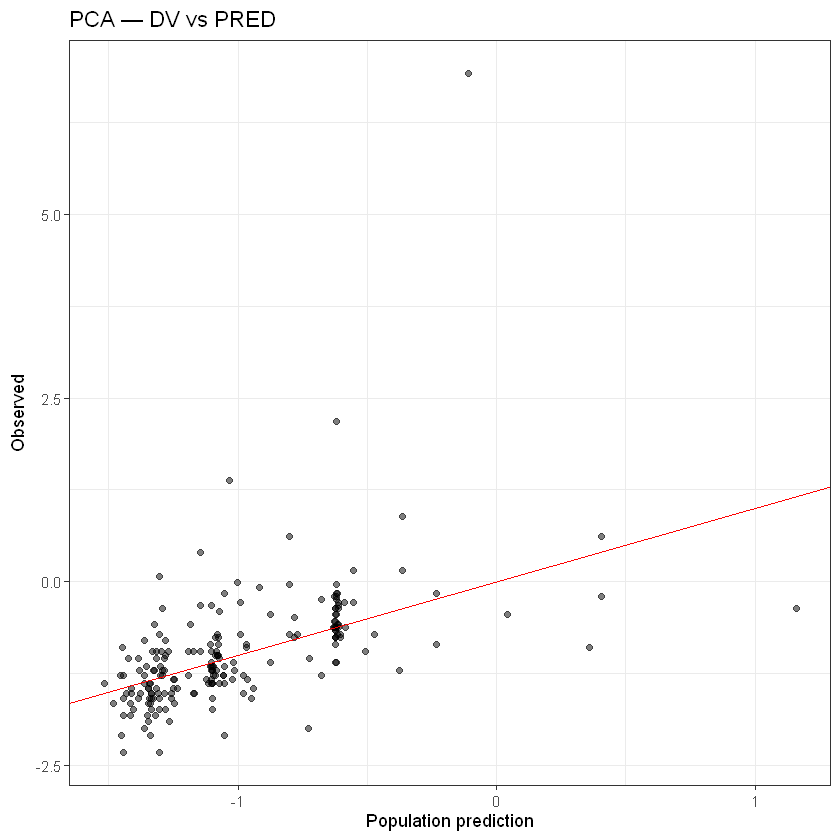

 

 

ℹ using population uncertainty from fitted model (`thetaMat`)

ℹ using `dfObs=483` from the number of observations in fitted model

ℹ using `dfSub=32` from the number of subjects in fitted model

ℹ using diagonal `sigma` based on model

 

 




VPC simulation successful. Proceeding to VPC plots.


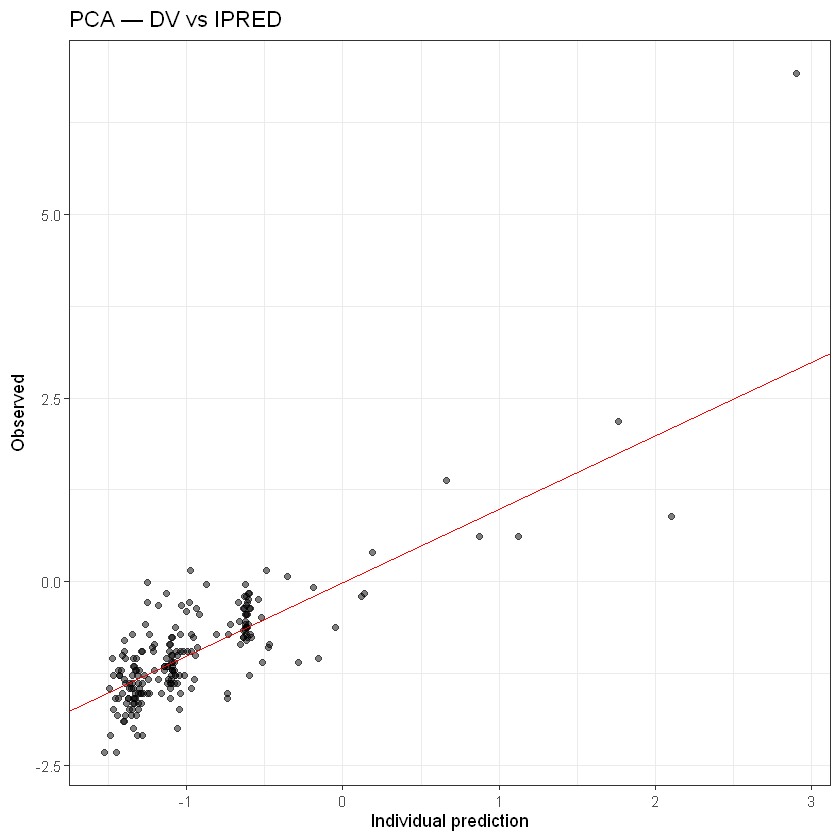

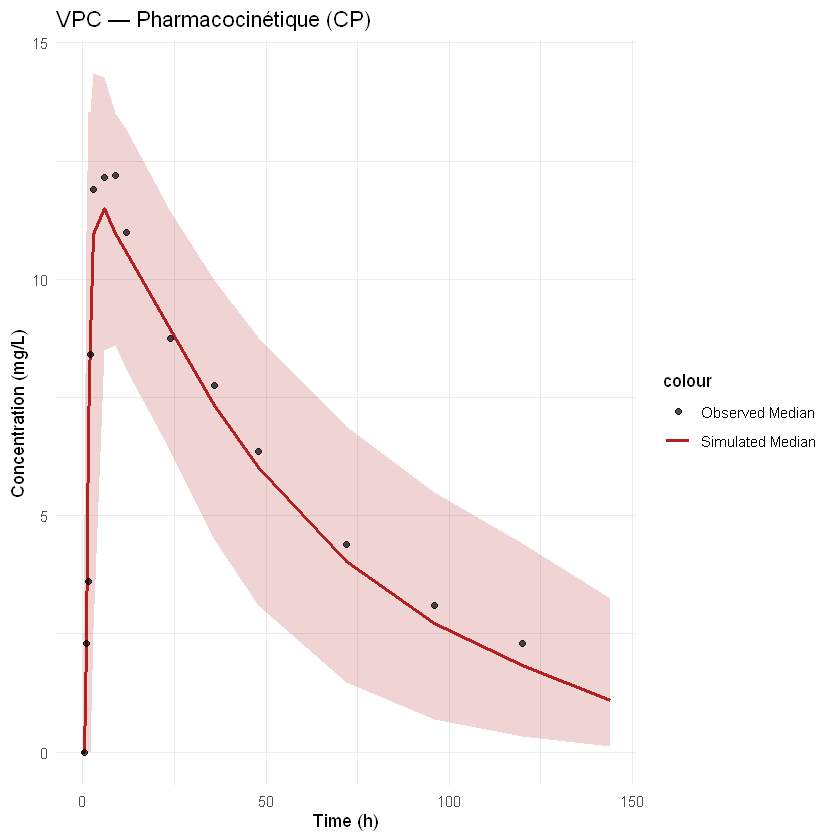

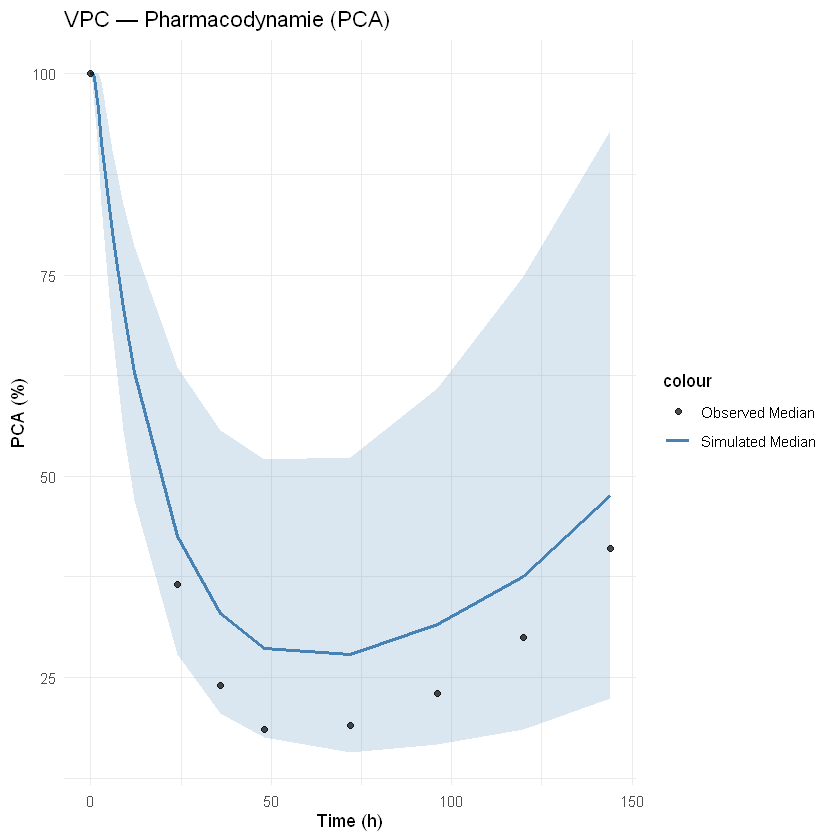

In [35]:
# =============================================================================
# 9) PK/PD diagnostics
# =============================================================================

pkpd_df <- nlmixr2(fit_pkpd_final)

# DV vs PRED for PCA observations
if (all(c("DV", "IPRED","PRED", "CMT") %in% names(pkpd_df))) {
  pca_df <- pkpd_df %>% filter(CMT == "pca", !is.na(DV))
  if (nrow(pca_df) > 0) {
    print(
      ggplot(pca_df, aes(x = PRED, y = DV)) +
        geom_point(alpha = 0.5) +
        geom_abline(slope = 1, intercept = 0, colour = "red") +
        labs(title = "PCA — DV vs PRED", x = "Population prediction", y = "Observed")
    )
    print(
      ggplot(pca_df, aes(x = IPRED, y = DV)) +
        geom_point(alpha = 0.5) +
        geom_abline(slope = 1, intercept = 0, colour = "red") +
        labs(title = "PCA — DV vs IPRED", x = "Individual prediction", y = "Observed")
    )
  }
}

# 1. Fonction inverse-logit
inv_logit_pca <- function(x) {
  100.1 * exp(x) / (1 + exp(x))
}

sim_vpc <- tryCatch(
    simulate(fit_pkpd_final, events = dat, nsim = 200, seed = 123),
    error = function(e) { message("VPC simulation failed:", conditionMessage(e)); NULL }
)
if (is.null(sim_vpc)) {
  cat("\nSkipping VPC plots due to simulation failure.\n")
} else {
  cat("\nVPC simulation successful. Proceeding to VPC plots.\n")
}

# 2. Conversion simple
sim_df <- as.data.frame(sim_vpc)

# ==========================================
# VPC Pharmacocinétique (PK)
# ==========================================
vpc_pk <- sim_df %>%
  group_by(time) %>%
  summarise(
    # On utilise la colonne 'cp' directement. 
    # pmax(0, ...) empêche les valeurs négatives du bruit résiduel.
    p5  = quantile(pmax(0, cp), 0.05, na.rm = TRUE),
    p50 = quantile(pmax(0, cp), 0.50, na.rm = TRUE),
    p95 = quantile(pmax(0, cp), 0.95, na.rm = TRUE),
    .groups = "drop"
  )

obs_pk <- dat %>% filter(dvid == "cp", evid == 0, !is.na(dv)) %>% 
  group_by(time) %>% summarise(obs50 = median(dv), .groups = "drop")

p_pk <- ggplot(vpc_pk, aes(x = time)) +
  geom_ribbon(aes(ymin = p5, ymax = p95), alpha = 0.2, fill = "firebrick") +
  geom_line(aes(y = p50, color = "Simulated Median"), size = 1) +
  geom_point(data = obs_pk, aes(y = obs50, color = "Observed Median"), alpha = 0.7, size = 1.5) +
  scale_color_manual(values = c("Simulated Median" = "firebrick", "Observed Median" = "black")) +
  labs(title = "VPC — Pharmacocinétique (CP)", x = "Time (h)", y = "Concentration (mg/L)") +
  theme_minimal()

print(p_pk)

# ==========================================
# VPC Pharmacodynamie (PCA)
# ==========================================
vpc_pd <- sim_df %>%
  group_by(time) %>%
  summarise(
    # On utilise la colonne 'pca' et on applique l'inverse logit
    p5  = inv_logit_pca(quantile(pca, 0.05, na.rm = TRUE)),
    p50 = inv_logit_pca(quantile(pca, 0.50, na.rm = TRUE)),
    p95 = inv_logit_pca(quantile(pca, 0.95, na.rm = TRUE)),
    .groups = "drop"
  )

obs_pd <- dat %>% filter(dvid == "pca", evid == 0, !is.na(dv)) %>% 
  group_by(time) %>% summarise(obs50 = median(dv), .groups = "drop")

p_pd <- ggplot(vpc_pd, aes(x = time)) +
  geom_ribbon(aes(ymin = p5, ymax = p95), alpha = 0.2, fill = "steelblue") +
  geom_line(aes(y = p50, color = "Simulated Median"), size = 1) +
  geom_point(data = obs_pd, aes(y = obs50, color = "Observed Median"), alpha = 0.7, size = 1.5) +
  scale_color_manual(values = c("Simulated Median" = "steelblue", "Observed Median" = "black")) +
  labs(title = "VPC — Pharmacodynamie (PCA)", x = "Time (h)", y = "PCA (%)") +
  theme_minimal()

print(p_pd)

## 12 — Virtual Clinical Trial Simulation

### Trial design (from the Monolix tutorial)
Two warfarin dosing regimens are compared:

| Group | Regimen |
|-------|---------|
| **Loading** | 20 mg at 0 h and 24 h, then 10 mg/day from 48 h to 312 h |
| **No loading** | 10 mg/day from 0 h to 312 h |

**Endpoint**: proportion of subjects with PCA(96 h) < 35%  
**Group size**: 100 subjects per arm, covariates sampled from the observed population

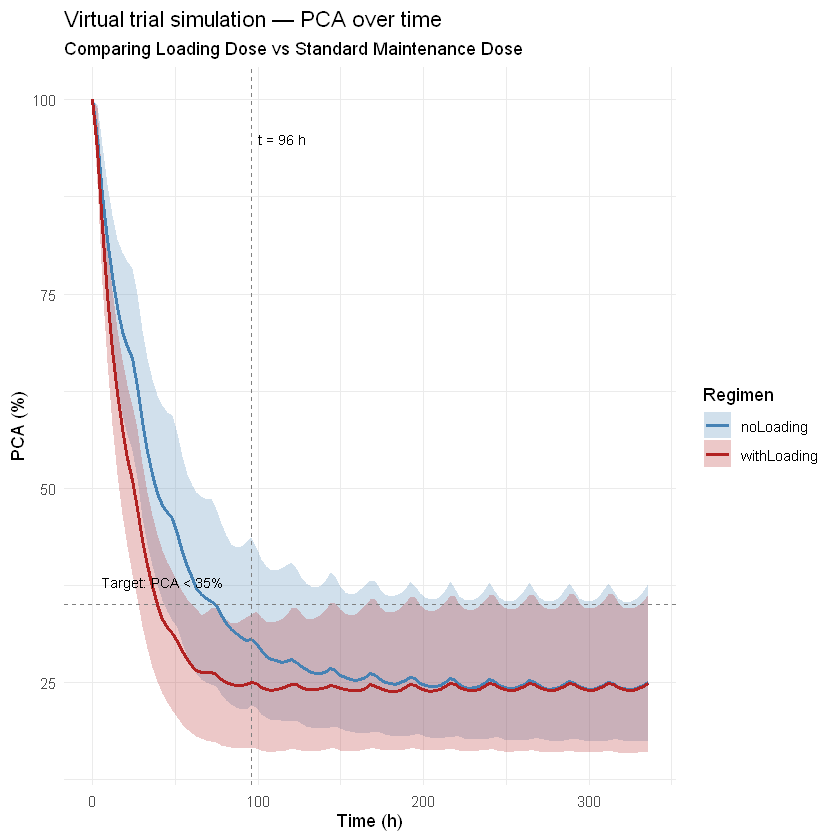

In [36]:

# =============================================================================
# 10) Clinical trial simulation
# =============================================================================

stopifnot(!is.null(fit_pkpd_final))

# 1. Fonction inverse-logit pour la PCA
inv_logit_pca <- function(x) {
  100.1 * exp(x) / (1 + exp(x))
}

cov_base <- dat %>% distinct(id, wt, age, sex)

sample_cov <- function(n, seed = 1) {
  set.seed(seed)
  cov_base %>%
    slice_sample(n = n, replace = TRUE) %>%
    mutate(id = seq_len(n))
}

make_trial_data <- function(cov_df, group = c("withLoading", "noLoading")) {
  group <- match.arg(group)

  if (group == "withLoading") {
    # Dose de charge : 20 mg à t=0 et t=24, puis entretien 10 mg
    dose_times <- c(0, 24, seq(48, 312, by = 24))
    dose_amts  <- c(20, 20, rep(10, length(seq(48, 312, by = 24))))
  } else {
    # Pas de charge : 10 mg en continu
    dose_times <- seq(0, 312, by = 24)
    dose_amts  <- rep(10, length(dose_times))
  }

  obs_times <- seq(0, 336, by = 3)

  purrr::map_dfr(seq_len(nrow(cov_df)), function(i) {
    id_i <- cov_df$id[i]
    # AJOUT : cmt = "depot" pour les doses
    doses <- data.frame(
      id = id_i, time = dose_times, amt = dose_amts, evid = 1L, cmt = "depot"
    )
    # AJOUT : cmt = "pca" pour cibler l'observation
    obs <- data.frame(
      id = id_i, time = obs_times, amt = 0, evid = 0L, cmt = "pca"
    )
    bind_rows(doses, obs) %>%
      left_join(cov_df %>% filter(id == id_i), by = "id") %>%
      arrange(time, desc(evid)) # On s'assure que la dose arrive avant l'observation au même temps
  }) %>% mutate(group = group)
}

# 2. Création des jeux de données (N = 100 par groupe)
cov_g1 <- sample_cov(100, seed = 1001)
cov_g2 <- sample_cov(100, seed = 1002)

trial_g1 <- make_trial_data(cov_g1, "withLoading")
trial_g2 <- make_trial_data(cov_g2, "noLoading")

# Simulation (cette fois ça passe !)
sim1 <- as.data.frame(simulate(fit_pkpd_final, events = trial_g1, nsim = 1, seed = 1)) %>% 
  mutate(group = "withLoading")

sim2 <- as.data.frame(simulate(fit_pkpd_final, events = trial_g2, nsim = 1, seed = 2)) %>% 
  mutate(group = "noLoading")

sim_all <- bind_rows(sim1, sim2)

# 4. Calcul des percentiles (en appliquant l'inverse logit sur la colonne simulée)
band <- sim_all %>%
  # On exclut les temps de dose (evid=1) qui pourraient polluer la courbe
  filter(!is.na(pca)) %>% 
  group_by(group, time) %>%
  summarise(
    # 'sim' est souvent le nom donné par défaut à la variable finale dans simulate()
    # Si 'sim' n'existe pas, utilisez 'pca'
    p5  = inv_logit_pca(quantile(pca, .05, na.rm = TRUE)),
    p50 = inv_logit_pca(quantile(pca, .50, na.rm = TRUE)),
    p95 = inv_logit_pca(quantile(pca, .95, na.rm = TRUE)),
    .groups = "drop"
  )

# 5. Graphique
p_trial <- ggplot(band, aes(x = time)) +
  geom_ribbon(aes(ymin = p5, ymax = p95, fill = group), alpha = 0.25) +
  geom_line(aes(y = p50, colour = group), size = 1) +
  # Lignes de référence pour le critère clinique
  geom_vline(xintercept = 96, linetype = "dashed", color = "grey50") +
  geom_hline(yintercept = 35, linetype = "dashed", color = "grey50") +
  annotate("text", x = 100, y = 95, label = "t = 96 h", hjust = 0, size = 3) +
  annotate("text", x = 5, y = 38, label = "Target: PCA < 35%", hjust = 0, size = 3) +
  scale_color_manual(values = c("withLoading" = "firebrick", "noLoading" = "steelblue")) +
  scale_fill_manual(values = c("withLoading" = "firebrick", "noLoading" = "steelblue")) +
  labs(
    title = "Virtual trial simulation — PCA over time",
    subtitle = "Comparing Loading Dose vs Standard Maintenance Dose",
    x = "Time (h)", y = "PCA (%)", fill = "Regimen", colour = "Regimen"
  ) +
  theme_minimal()

print(p_trial)


## 13 — Endpoint Analysis

We compare the proportion of subjects achieving PCA(96 h) < 35% between regimens  
using a **one-sided Fisher exact test** (H₁: loading > no-loading).

In [37]:
# =============================================================================
# 11) Endpoint: PCA(96h) < 35%
# =============================================================================

endpoint_96h <- sim_all %>%
  filter(time == 96) %>%
  mutate(pca_nat = inv_logit_pca(pca)) %>%
  group_by(group) %>%
  summarise(
    n_patients = n(),
    success_rate = mean(pca_nat < 35) * 100,
    median_pca = median(pca_nat),
    .groups = "drop"
  )

cat("\n--- Clinical Endpoint at 96 hours (Target PCA < 35%) ---\n")
print(endpoint_96h)



--- Clinical Endpoint at 96 hours (Target PCA < 35%) ---
# A tibble: 2 × 4
  group       n_patients success_rate median_pca
  <chr>            <int>        <dbl>      <dbl>
1 noLoading          100           65       30.5
2 withLoading        100           96       25.0


## 15 — Conclusion

This notebook reproduced the Monolix warfarin PK/PD tutorial using **nlmixr2 / rxode2**, including:

- **Sequential PK development**: structural model selection (1-cmt + Tlag), residual error model (combined2), and covariate (weight on V)
- **PK/PD comparison**: indirect response vs effect compartment — the turnover model was preferred (lower BIC)
- **Virtual trial simulation**: loading vs no-loading regimens, clinical endpoint PCA(96h) < 35%, statistical power via replications


In [38]:
sessionInfo()

R version 4.4.1 (2024-06-14 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default


locale:
[1] LC_COLLATE=French_France.utf8  LC_CTYPE=French_France.utf8    LC_MONETARY=French_France.utf8
[4] LC_NUMERIC=C                   LC_TIME=French_France.utf8    

time zone: Europe/Paris
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] stringr_1.6.0      ggplot2_4.0.2      purrr_1.0.2        tidyr_1.3.1        dplyr_1.1.4        rxode2_4.1.1      
 [7] nlmixr2plot_5.0.1  nlmixr2extra_3.0.2 nlmixr2est_3.0.4   nlmixr2data_2.0.9  lotri_1.0.2        nlmixr2_5.0.0     

loaded via a namespace (and not attached):
 [1] utf8_1.2.4          generics_0.1.3      stringi_1.8.4       lattice_0.22-6      digest_0.6.37      
 [6] magrittr_2.0.3      evaluate_1.0.3      grid_4.4.1          RColorBrewer_1.1-3  pbdZMQ_0.3-14      
[11] fastmap_1.2.0      